# Proyecto de Deep Learning - Clasificacion de Imagenes de Perros y Gatos

**Objetivo del proyecto:**

1. Comprender un dataset nuevo de imagenes
2. Visualizar la informacion de entrada y normalizar los tamanos
3. Construir una red neuronal con la arquitectura EfficientNet-B0
4. Optimizar el modelo con `ModelCheckpoint` y `EarlyStopping`
5. Guardar el modelo

In [1]:
# Your code here
import os
import shutil
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from keras.applications import EfficientNetB0
from keras.models import Sequential, load_model
from keras.layers import Dense, GlobalAveragePooling2D
from keras.callbacks import ModelCheckpoint, EarlyStopping

print("TensorFlow:", tf.__version__)
print("Keras:", tf.keras.__version__)
print("GPU disponible:", len(tf.config.list_physical_devices("GPU")) > 0)

TensorFlow: 2.22.0-rc0
Keras: 3.16.0.dev2026092318
GPU disponible: False


In [3]:
#Ruta a la carpeta con las imagenes originales
source_folder = "/Users/jonat/OneDrive/Desktop/4geeks/Machine-Learning-image-classifier-project/data/raw/dogs-vs-cats/dogs-vs-cats/train"

all_files = os.listdir(source_folder)

dog_files = []
cat_files = []

for file_name in all_files:
    if file_name.startswith("dog"):
        dog_files.append(file_name)
    elif file_name.startswith("cat"):
        cat_files.append(file_name)

print("Total de imagenes:", len(all_files))
print("Perros:", len(dog_files))
print("Gatos:", len(cat_files))

Total de imagenes: 25000
Perros: 12500
Gatos: 12500


## Informacion de entrada

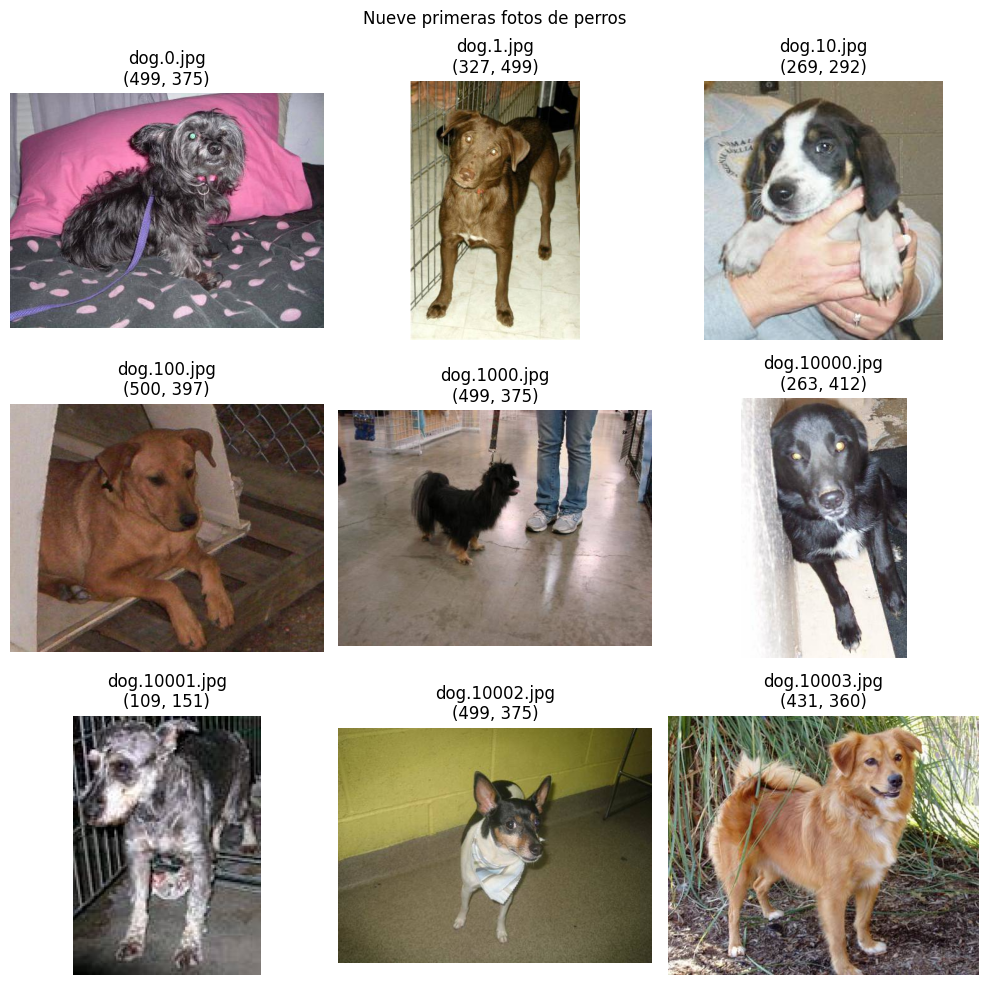

In [4]:
#Primeras nueve fotos de perros
from keras.utils import load_img

dog_files.sort()

plt.figure(figsize = (10, 10))

for i in range(9):
    plt.subplot(3, 3, i + 1)
    image = load_img(os.path.join(source_folder, dog_files[i]))
    plt.imshow(image)
    plt.title(dog_files[i] + "\n" + str(image.size))
    plt.axis("off")

plt.suptitle("Nueve primeras fotos de perros")
plt.tight_layout()
plt.show()

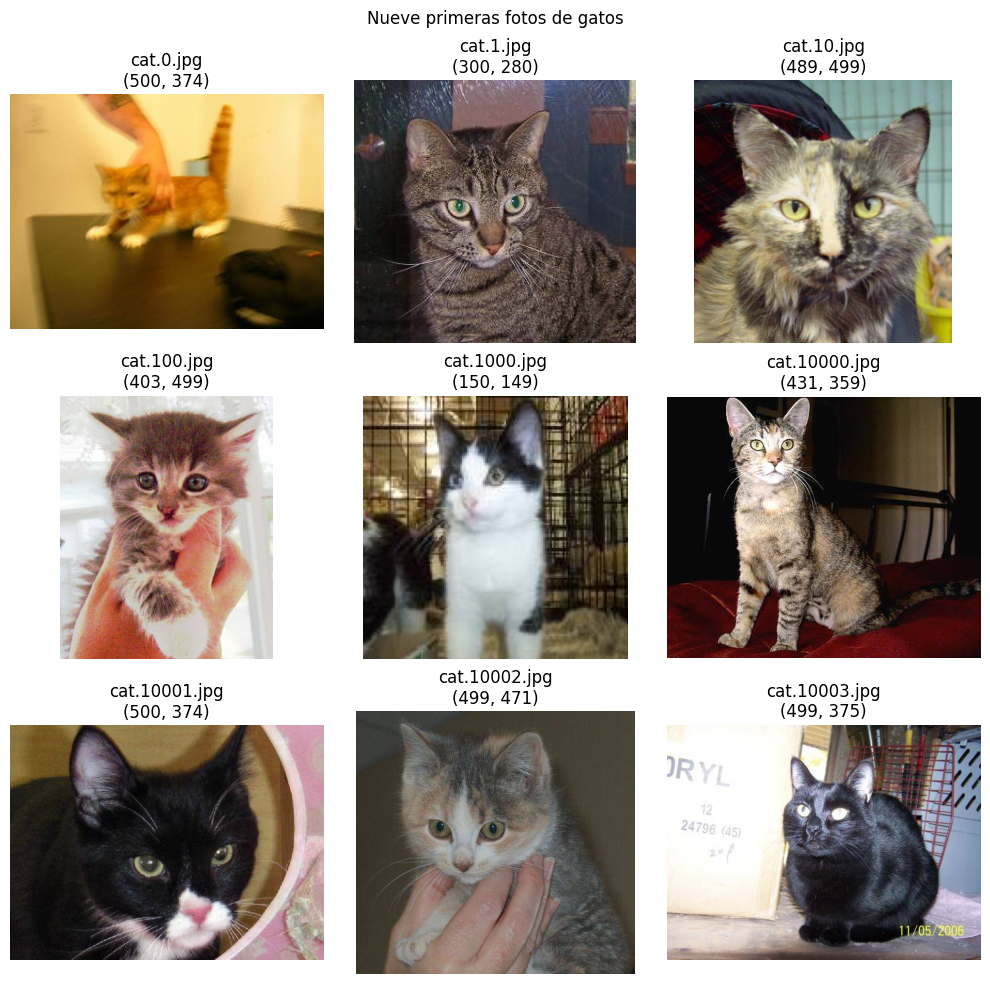

In [5]:
#Primeras nueve fotos de gatos
cat_files.sort()

plt.figure(figsize = (10, 10))

for i in range(9):
    plt.subplot(3, 3, i + 1)
    image = load_img(os.path.join(source_folder, cat_files[i]))
    plt.imshow(image)
    plt.title(cat_files[i] + "\n" + str(image.size))
    plt.axis("off")

plt.suptitle("Nueve primeras fotos de gatos")
plt.tight_layout()
plt.show()

       ancho   alto
count  200.0  200.0
mean   403.6  357.7
std    108.7  102.2
min    105.0   90.0
25%    323.8  292.0
50%    448.0  374.0
75%    499.0  427.2
max    500.0  500.0


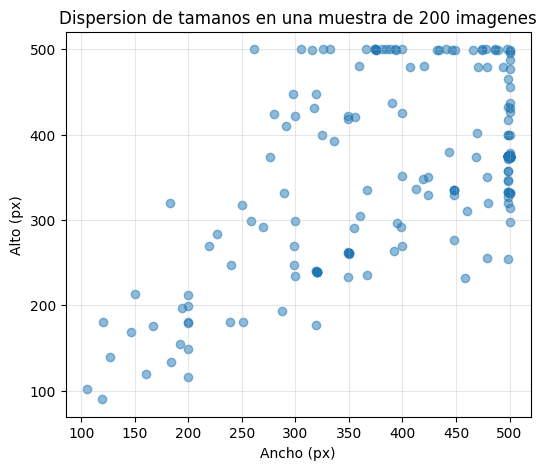

In [6]:
#Comprobacion de la variedad de tamanos sobre una muestra
sample_files = random.sample(all_files, 200)

widths = []
heights = []

for file_name in sample_files:
    image = load_img(os.path.join(source_folder, file_name))
    widths.append(image.size[0])
    heights.append(image.size[1])

size_table = pd.DataFrame()
size_table["ancho"] = widths
size_table["alto"] = heights

print(size_table.describe().round(1))

plt.figure(figsize = (6, 5))
plt.scatter(widths, heights, alpha = 0.5)
plt.xlabel("Ancho (px)")
plt.ylabel("Alto (px)")
plt.title("Dispersion de tamanos en una muestra de 200 imagenes")
plt.grid(alpha = 0.3)
plt.show()

In [7]:
#Creacion de la estructura de carpetas que espera flow_from_directory
base_folder = "/Users/jonat/OneDrive/Desktop/4geeks/Machine-Learning-image-classifier-project/data/processed"

shutil.rmtree(base_folder, ignore_errors = True)

for subset in ["train", "test"]:
    for class_name in ["dog", "cat"]:
        os.makedirs(os.path.join(base_folder, subset, class_name), exist_ok = True)

print("Estructura creada:")
for subset in ["train", "test"]:
    for class_name in ["dog", "cat"]:
        print("  ", os.path.join(base_folder, subset, class_name))

Estructura creada:
   /Users/jonat/OneDrive/Desktop/4geeks/Machine-Learning-image-classifier-project/data/processed\train\dog
   /Users/jonat/OneDrive/Desktop/4geeks/Machine-Learning-image-classifier-project/data/processed\train\cat
   /Users/jonat/OneDrive/Desktop/4geeks/Machine-Learning-image-classifier-project/data/processed\test\dog
   /Users/jonat/OneDrive/Desktop/4geeks/Machine-Learning-image-classifier-project/data/processed\test\cat


In [8]:
#Reparto de las imagenes en train (80%) y test (20%)
random.seed(42)
random.shuffle(all_files)

split_point = int(len(all_files) * 0.8)

train_files = all_files[:split_point]
test_files = all_files[split_point:]

for file_name in train_files:
    class_name = file_name.split(".")[0]
    shutil.copy(os.path.join(source_folder, file_name),
                os.path.join(base_folder, "train", class_name, file_name))

for file_name in test_files:
    class_name = file_name.split(".")[0]
    shutil.copy(os.path.join(source_folder, file_name),
                os.path.join(base_folder, "test", class_name, file_name))

print("Imagenes en train:", len(train_files))
print("Imagenes en test: ", len(test_files))

Imagenes en train: 20000
Imagenes en test:  5000


In [9]:
#Recuento por clase tras el reparto
for subset in ["train", "test"]:
    for class_name in ["dog", "cat"]:
        folder = os.path.join(base_folder, subset, class_name)
        print(subset, "/", class_name, "->", len(os.listdir(folder)), "imagenes")

train / dog -> 9979 imagenes
train / cat -> 10021 imagenes
test / dog -> 2521 imagenes
test / cat -> 2479 imagenes


### Creacion de los generadores de imagenes

In [10]:
image_size = (224, 224)
batch_size = 32

trdata = ImageDataGenerator()
train_generator = trdata.flow_from_directory(
    os.path.join(base_folder, "train"),
    target_size = image_size,
    batch_size = batch_size,
    class_mode = "categorical"
)

tsdata = ImageDataGenerator()
test_generator = tsdata.flow_from_directory(
    os.path.join(base_folder, "test"),
    target_size = image_size,
    batch_size = batch_size,
    class_mode = "categorical",
    shuffle = False
)

print("")
print("Correspondencia clase - indice:", train_generator.class_indices)

Found 20000 images belonging to 2 classes.
Found 5000 images belonging to 2 classes.

Correspondencia clase - indice: {'cat': 0, 'dog': 1}


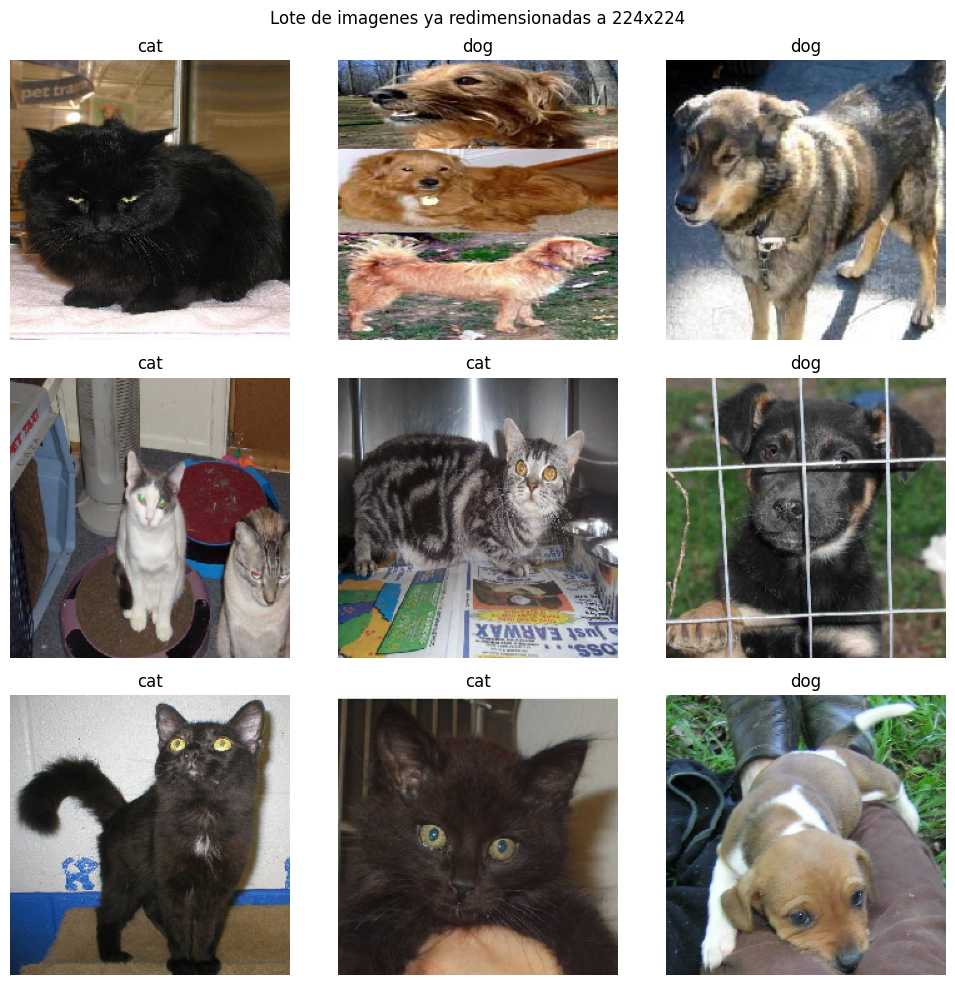

Forma del lote de imagenes: (32, 224, 224, 3)
Forma del lote de etiquetas: (32, 2)


In [11]:
#Visualizacion de un lote ya procesado
images, labels = next(train_generator)

class_names = list(train_generator.class_indices.keys())

images_to_show = min(9, len(images))

plt.figure(figsize = (10, 10))

for i in range(images_to_show):
    plt.subplot(3, 3, i + 1)
    plt.imshow(images[i].astype("uint8"))
    plt.title(class_names[np.argmax(labels[i])])
    plt.axis("off")

plt.suptitle("Lote de imagenes ya redimensionadas a 224x224")
plt.tight_layout()
plt.show()

print("Forma del lote de imagenes:", images.shape)
print("Forma del lote de etiquetas:", labels.shape)

## RNA

In [12]:
model = Sequential()
model.add(EfficientNetB0(include_top = False, weights = None, input_shape = (224, 224, 3)))
model.add(GlobalAveragePooling2D())
model.add(Dense(units = 128, activation = "relu"))
model.add(Dense(units = 2, activation = "softmax"))

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ efficientnetb0 (Functional)     │ (None, 7, 7, 1280)     │     4,049,571 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 2)              │           258 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,213,797 (16.07 MB)

 Trainable params: 4,171,774 (15.91 MB)

 Non-trainable params: 42,023 (164.16 KB)

In [13]:
from keras.optimizers import Adam

model.compile(
    optimizer = Adam(learning_rate = 0.0001),
    loss = "categorical_crossentropy",
    metrics = ["accuracy"]
)

print("Parametros totales:", model.count_params())

Parametros totales: 4213797


In [14]:
#Entrenamiento inicial
#Ajusta las epocas segun el tiempo del que dispongas: en CPU cada epoca puede tardar mucho
initial_epochs = 5

history = model.fit(
    train_generator,
    validation_data = test_generator,
    epochs = initial_epochs,
    verbose = 1
)

Epoch 1/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 1136s 2s/step - accuracy: 0.6072 - loss: 0.6625 - val_accuracy: 0.6504 - val_loss: 0.6344
Epoch 2/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 1096s 2s/step - accuracy: 0.6663 - loss: 0.6110 - val_accuracy: 0.6770 - val_loss: 0.6478
Epoch 3/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 1129s 2s/step - accuracy: 0.7059 - loss: 0.5679 - val_accuracy: 0.7260 - val_loss: 0.5637
Epoch 4/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 1128s 2s/step - accuracy: 0.7467 - loss: 0.5178 - val_accuracy: 0.7558 - val_loss: 0.5262
Epoch 5/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 1097s 2s/step - accuracy: 0.7746 - loss: 0.4718 - val_accuracy: 0.7636 - val_loss: 0.5093


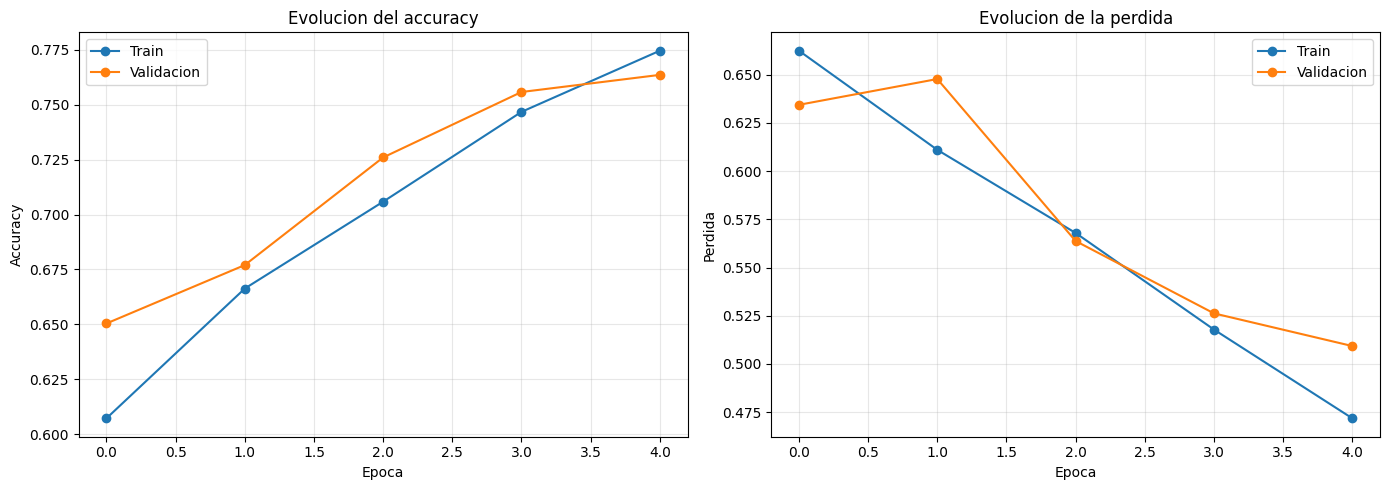

In [15]:
#Curvas de entrenamiento
fig, axis = plt.subplots(1, 2, figsize = (14, 5))

axis[0].plot(history.history["accuracy"], marker = "o", label = "Train")
axis[0].plot(history.history["val_accuracy"], marker = "o", label = "Validacion")
axis[0].set_xlabel("Epoca")
axis[0].set_ylabel("Accuracy")
axis[0].set_title("Evolucion del accuracy")
axis[0].legend()
axis[0].grid(alpha = 0.3)

axis[1].plot(history.history["loss"], marker = "o", label = "Train")
axis[1].plot(history.history["val_loss"], marker = "o", label = "Validacion")
axis[1].set_xlabel("Epoca")
axis[1].set_ylabel("Perdida")
axis[1].set_title("Evolucion de la perdida")
axis[1].legend()
axis[1].grid(alpha = 0.3)

plt.tight_layout()
plt.show()

In [16]:
#Rendimiento del modelo inicial
initial_loss, initial_accuracy = model.evaluate(test_generator, verbose = 1)

print("")
print("Perdida en test:", round(initial_loss, 4))
print("Accuracy en test:", round(initial_accuracy, 4))

157/157 ━━━━━━━━━━━━━━━━━━━━ 41s 259ms/step - accuracy: 0.7636 - loss: 0.5093

Perdida en test: 0.5093
Accuracy en test: 0.7636


## Optimizacion

In [17]:
os.makedirs("./modelos_ml", exist_ok = True)

checkpoint = ModelCheckpoint(
    filepath = "./modelos_ml/best_model.keras",
    monitor = "val_accuracy",
    save_best_only = True,
    mode = "max",
    verbose = 1
)

early_stopping = EarlyStopping(
    monitor = "val_accuracy",
    patience = 5,
    mode = "max",
    restore_best_weights = True,
    verbose = 1
)

print("Callbacks creados")

Callbacks creados


In [18]:
#Modelo reconstruido desde cero para el entrenamiento optimizado
optimized_model = Sequential()
optimized_model.add(EfficientNetB0(include_top = False, weights = None, input_shape = (224, 224, 3)))
optimized_model.add(GlobalAveragePooling2D())
optimized_model.add(Dense(units = 128, activation = "relu"))
optimized_model.add(Dense(units = 2, activation = "softmax"))

optimized_model.compile(
    optimizer = Adam(learning_rate = 0.0001),
    loss = "categorical_crossentropy",
    metrics = ["accuracy"]
)

optimized_history = optimized_model.fit(
    train_generator,
    validation_data = test_generator,
    epochs = 30,
    callbacks = [checkpoint, early_stopping],
    verbose = 1
)

Epoch 1/30
625/625 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.5918 - loss: 0.6765
Epoch 1: val_accuracy improved from None to 0.64380, saving model to ./modelos_ml/best_model.keras

Epoch 1: finished saving model to ./modelos_ml/best_model.keras
625/625 ━━━━━━━━━━━━━━━━━━━━ 1074s 2s/step - accuracy: 0.5918 - loss: 0.6765 - val_accuracy: 0.6438 - val_loss: 0.6351
Epoch 2/30
625/625 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.6526 - loss: 0.6245
Epoch 2: val_accuracy improved from 0.64380 to 0.68280, saving model to ./modelos_ml/best_model.keras

Epoch 2: finished saving model to ./modelos_ml/best_model.keras
625/625 ━━━━━━━━━━━━━━━━━━━━ 1106s 2s/step - accuracy: 0.6526 - loss: 0.6245 - val_accuracy: 0.6828 - val_loss: 0.6055
Epoch 3/30
625/625 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.6973 - loss: 0.5776
Epoch 3: val_accuracy improved from 0.68280 to 0.71080, saving model to ./modelos_ml/best_model.keras

Epoch 3: finished saving model to ./modelos_ml/best_model.keras
625/625 ━

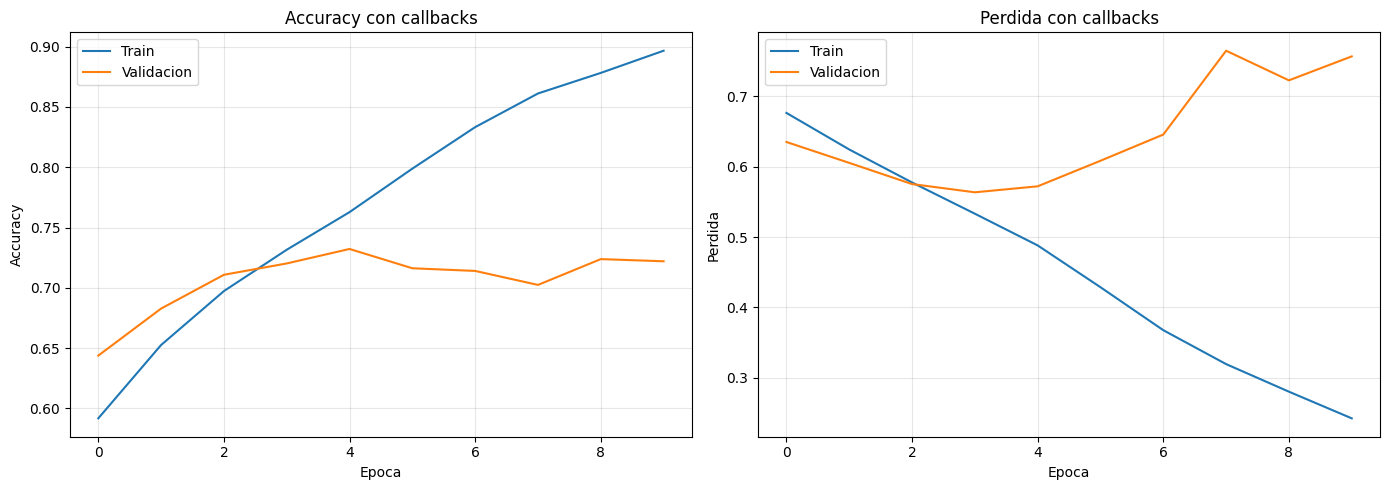

Epocas ejecutadas: 10
Mejor accuracy de validacion: 0.7322


In [19]:
#Curvas del entrenamiento optimizado
fig, axis = plt.subplots(1, 2, figsize = (14, 5))

axis[0].plot(optimized_history.history["accuracy"], label = "Train")
axis[0].plot(optimized_history.history["val_accuracy"], label = "Validacion")
axis[0].set_xlabel("Epoca")
axis[0].set_ylabel("Accuracy")
axis[0].set_title("Accuracy con callbacks")
axis[0].legend()
axis[0].grid(alpha = 0.3)

axis[1].plot(optimized_history.history["loss"], label = "Train")
axis[1].plot(optimized_history.history["val_loss"], label = "Validacion")
axis[1].set_xlabel("Epoca")
axis[1].set_ylabel("Perdida")
axis[1].set_title("Perdida con callbacks")
axis[1].legend()
axis[1].grid(alpha = 0.3)

plt.tight_layout()
plt.show()

print("Epocas ejecutadas:", len(optimized_history.history["accuracy"]))
print("Mejor accuracy de validacion:", round(max(optimized_history.history["val_accuracy"]), 4))

### Carga del mejor modelo y prediccion sobre test

In [20]:
#Carga del mejor modelo guardado por ModelCheckpoint
best_model = load_model("./modelos_ml/best_model.keras")

final_loss, final_accuracy = best_model.evaluate(test_generator, verbose = 1)

print("")
print("Perdida en test:", round(final_loss, 4))
print("Accuracy en test:", round(final_accuracy, 4))

157/157 ━━━━━━━━━━━━━━━━━━━━ 42s 249ms/step - accuracy: 0.7322 - loss: 0.5721

Perdida en test: 0.5721
Accuracy en test: 0.7322


In [21]:
#Predicciones sobre el conjunto de test
predicted_probabilities = best_model.predict(test_generator, verbose = 1)
predicted_classes = np.argmax(predicted_probabilities, axis = 1)

real_classes = test_generator.classes

print("Predicciones realizadas:", len(predicted_classes))

157/157 ━━━━━━━━━━━━━━━━━━━━ 40s 247ms/step
Predicciones realizadas: 5000


In [22]:
#Metricas detalladas
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import seaborn as sns

print("Accuracy:", round(accuracy_score(real_classes, predicted_classes), 4))
print("")
print(classification_report(real_classes, predicted_classes,
                            target_names = class_names, digits = 3))

Accuracy: 0.7322

              precision    recall  f1-score   support

         cat      0.758     0.675     0.714      2479
         dog      0.712     0.788     0.748      2521

    accuracy                          0.732      5000
   macro avg      0.735     0.732     0.731      5000
weighted avg      0.735     0.732     0.731      5000



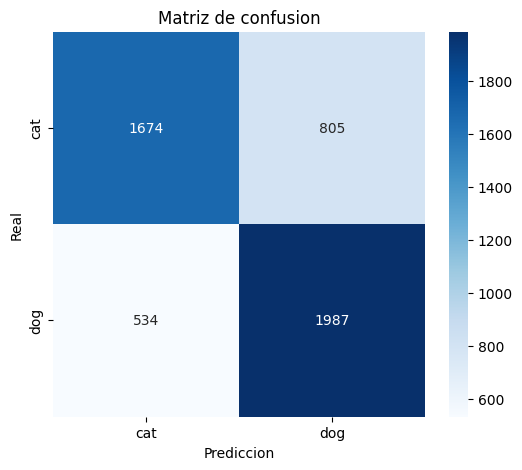

[[1674  805]
 [ 534 1987]]


In [23]:
#Matriz de confusion
plt.figure(figsize = (6, 5))
sns.heatmap(confusion_matrix(real_classes, predicted_classes), annot = True, fmt = "d",
            cmap = "Blues", xticklabels = class_names, yticklabels = class_names)
plt.xlabel("Prediccion")
plt.ylabel("Real")
plt.title("Matriz de confusion")
plt.show()

print(confusion_matrix(real_classes, predicted_classes))

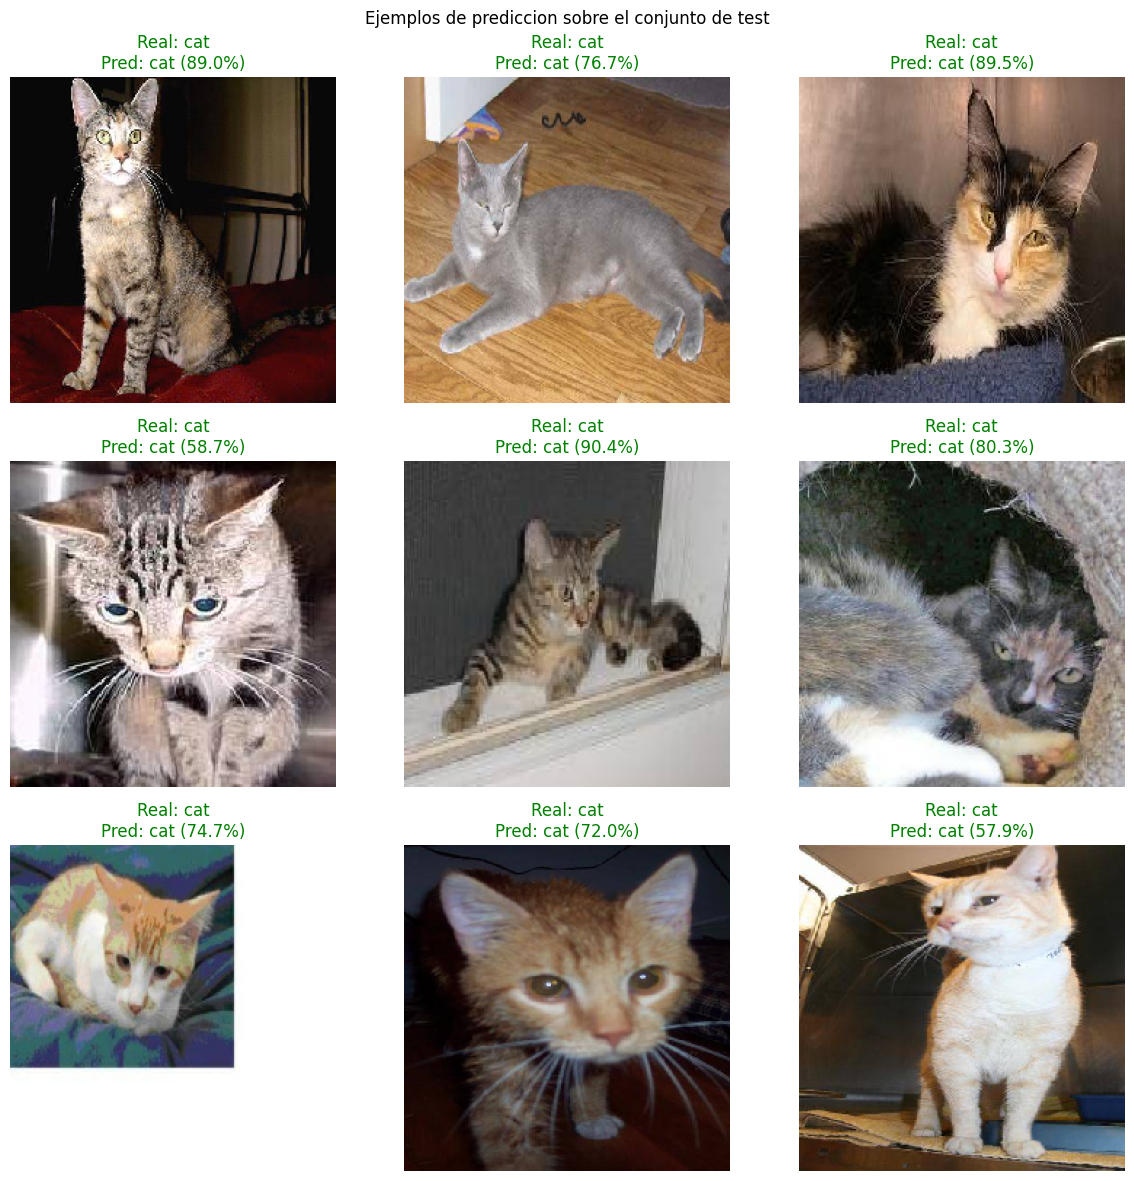

In [24]:
#Ejemplos de predicciones, incluyendo aciertos y fallos
test_file_names = test_generator.filenames

plt.figure(figsize = (12, 12))

for i in range(9):
    plt.subplot(3, 3, i + 1)
    image = load_img(os.path.join(base_folder, "test", test_file_names[i]), target_size = image_size)
    plt.imshow(image)

    real_label = class_names[real_classes[i]]
    predicted_label = class_names[predicted_classes[i]]
    confidence = predicted_probabilities[i].max()

    if real_label == predicted_label:
        title_color = "green"
    else:
        title_color = "red"

    plt.title("Real: " + real_label + "\nPred: " + predicted_label +
              " (" + str(round(confidence * 100, 1)) + "%)", color = title_color)
    plt.axis("off")

plt.suptitle("Ejemplos de prediccion sobre el conjunto de test")
plt.tight_layout()
plt.show()

In [25]:
#Comparacion entre el modelo inicial y el optimizado
comparison = pd.DataFrame()
comparison["modelo"] = ["Inicial (sin callbacks)", "Optimizado (con callbacks)"]
comparison["epocas"] = [initial_epochs, len(optimized_history.history["accuracy"])]
comparison["accuracy test"] = [initial_accuracy, final_accuracy]
comparison["perdida test"] = [initial_loss, final_loss]
comparison = comparison.round(4)

comparison

,modelo,epocas,accuracy test,perdida test
0,Inicial (sin callbacks),5,0.7636,0.5093
1,Optimizado (con callbacks),10,0.7322,0.5721


## Guardar el Modelo

In [26]:
#ModelCheckpoint ya guardo el mejor modelo, pero se guarda tambien la version final
best_model.save("./modelos_ml/dogs_cats_model.keras")

print("Modelos guardados en ./modelos_ml/")
for file_name in os.listdir("./modelos_ml"):
    file_path = os.path.join("./modelos_ml", file_name)
    size_mb = round(os.path.getsize(file_path) / (1024 * 1024), 2)
    print("  ", file_name, "-", size_mb, "MB")

Modelos guardados en ./modelos_ml/
   best_model.keras - 48.86 MB
   dogs_cats_model.keras - 48.85 MB
